# Task 4: Insurance Claim Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Dataset & Basic Exploration

In [3]:
# Load the dataset
df = pd.read_csv('insurance (1).csv') 

In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Dataset Shape: (1338, 7)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [5]:
print("\n=== First 5 Rows ===")
print(df.head())


=== First 5 Rows ===
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [6]:
print("\n=== Data Types ===")
print(df.dtypes)


=== Data Types ===
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [7]:
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [8]:
print("\n=== Basic Statistics ===")
print(df.describe())


=== Basic Statistics ===
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [9]:
print("\n=== Target Variable (charges) Statistics ===")
print(df['charges'].describe())


=== Target Variable (charges) Statistics ===
count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64


# Exploratory Data Analysis (EDA) + Important Visualizations

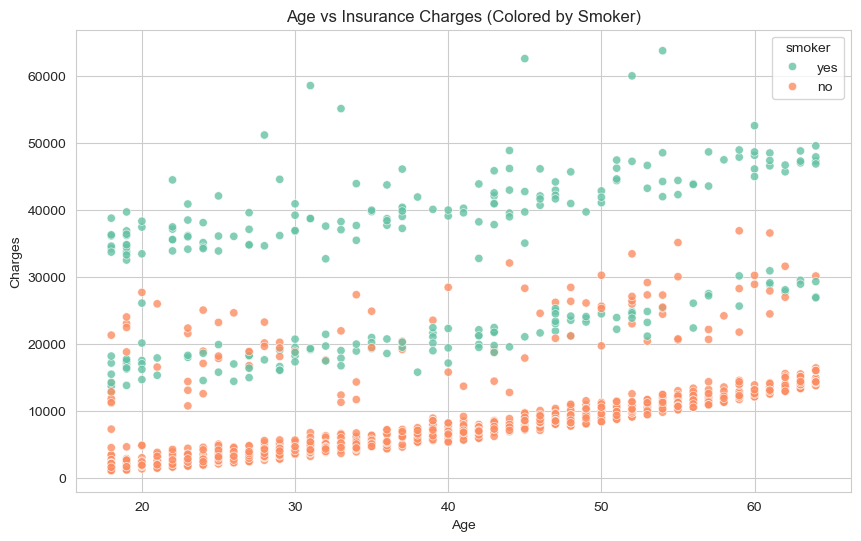

In [10]:
# 1. Age vs Charges
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, palette='Set2', alpha=0.8)
plt.title('Age vs Insurance Charges (Colored by Smoker)')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

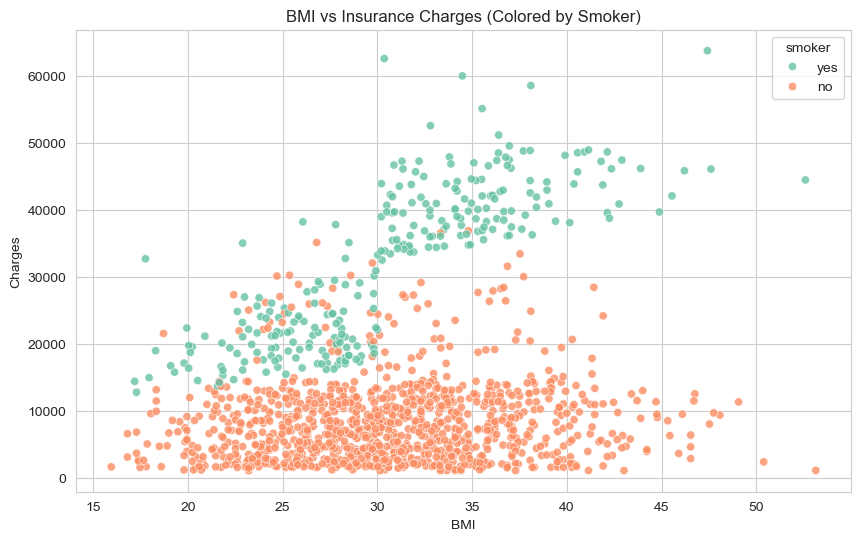

In [11]:
# 2. BMI vs Charges
plt.figure(figsize=(10,6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, palette='Set2', alpha=0.8)
plt.title('BMI vs Insurance Charges (Colored by Smoker)')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

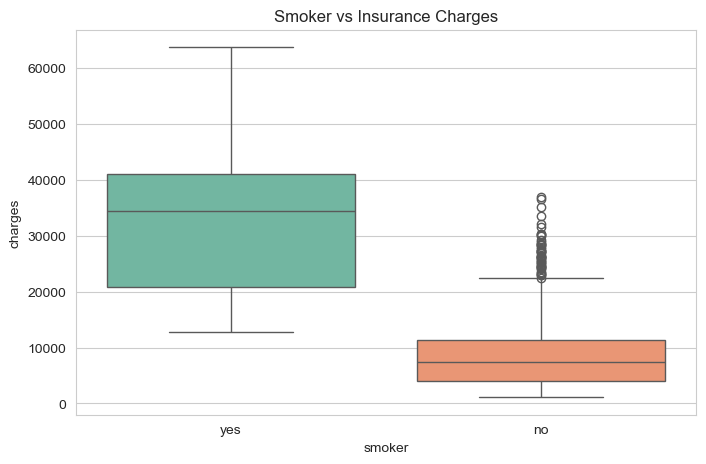

In [12]:
# 3. Smoker vs Charges
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Smoker vs Insurance Charges')
plt.show()

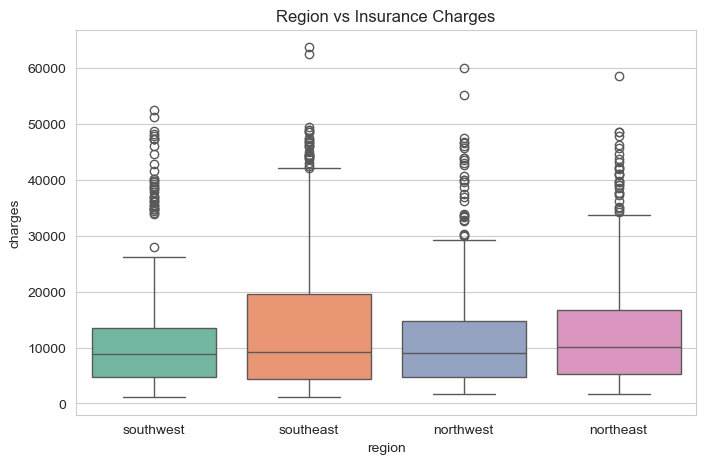

In [13]:
# 4. Region vs Charges
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=df, palette='Set2')
plt.title('Region vs Insurance Charges')
plt.show()

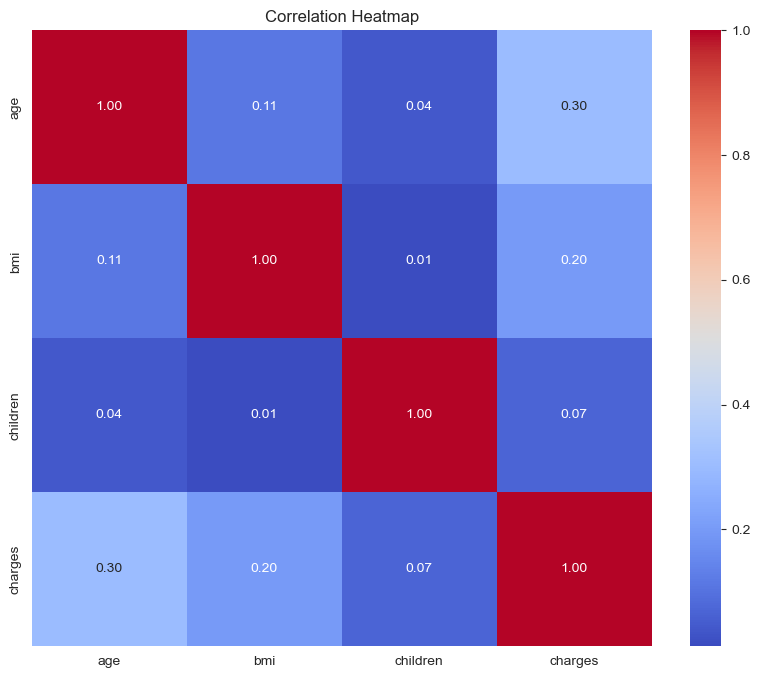

In [14]:
# 5. Correlation Heatmap
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#  Feature Encoding

In [15]:
# Create copy for modeling
df_model = df.copy()

# Label Encoding for binary columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_model['sex'] = le.fit_transform(df_model['sex'])
df_model['smoker'] = le.fit_transform(df_model['smoker'])

# One-Hot Encoding for Region
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True)

print("Shape after Encoding:", df_model.shape)
print("Columns:", df_model.columns.tolist())

Shape after Encoding: (1338, 9)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


# Train-Test Split & Linear Regression

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
# Separate Features and Target
X = df_model.drop('charges', axis=1)
y = df_model['charges']

In [18]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (1070, 8)
Testing Shape: (268, 8)


In [19]:
# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [20]:
# Predictions
y_pred = model.predict(X_test)

In [21]:
# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== Model Performance ===")
print("Mean Absolute Error (MAE) :", round(mae, 2))
print("Root Mean Square Error (RMSE):", round(rmse, 2))
print("R² Score:", round(model.score(X_test, y_test), 4))


=== Model Performance ===
Mean Absolute Error (MAE) : 4181.19
Root Mean Square Error (RMSE): 5796.28
R² Score: 0.7836


# Conclusion & Key Insights

## Task Summary
- Successfully built a Linear Regression model to predict medical insurance claim amounts.
- Dataset contains 1338 records with key features like age, bmi, smoker, etc.

## Model Performance
- **Mean Absolute Error (MAE)**: 4181.19
- **Root Mean Square Error (RMSE)**: 5796.28
- **R² Score**: 0.7836

## Key Visual Insights
- **Smoking Status** is the strongest factor — smokers have significantly higher claim amounts.
- **Age** has a strong positive correlation with charges (older people claim more).
- **BMI** also shows clear impact — higher BMI leads to higher charges, especially for smokers.
- Region and number of children have comparatively less impact.

## Business Recommendations
- Insurance company should charge higher premiums for **smokers** and people with **high BMI**.
- Age is an important risk factor — senior citizens tend to have higher medical costs.
- Targeted health programs for high-BMI and smoking customers can help reduce claims.

## Skills Applied
- Data Exploration and Visualization
- Feature Encoding (Label + One-Hot)
- Linear Regression Modeling
- Model Evaluation using MAE & RMSE
- Business Insights Generation

**This notebook fulfills all the requirements of Task 4 as per DevelopersHub guidelines.**